# WEIGHT CLASSIFIER
This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine to build a machine learning model capable of classifying a person's weight type based on their medical attributes. 

We're going yo take the following approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## PROBLEM DEFINITION
**Citation Request:** Koklu, N., & Sulak, S.A. (2024). Using artificial intelligence techniques for the analysis of obesity
status according to the individuals' social and physical activities. Sinop Üniversitesi Fen Bilimleri Dergisi, 9(1),
217-239. https://doi.org/10.33484/sinopfbd.1445215

**Obesity Dataset**

Obesity is a serious and chronic disease with genetic and environmental interactions. It is defined as an excessive amount of fat tissue in the body that is harmful to health. The main risk factors for obesity include social, psychological, and eating habits. Obesity is a significant health problem for all age groups in the world. Currently, more than 2 billion people worldwide are obese or overweight. Research has shown that obesity can be prevented. In this study, artificial intelligence methods were used to identify individuals at risk of obesity. An online survey was conducted on 1610 individuals to create the obesity dataset. 



## DATA
The data is from Koklu, N., & Sulak, S.A. (2024) project on kaggle

## EVALUATION
>If we can reach 95% accuracy at prediciting a person's weight class we'd explore the project.

## FEATURES
This is where you'll get different information about each of the features in your data.  You can do this via doing your own research (such as looking at the links above) or by talking to a subject matter expert (someone who knows about the dataset).

#### Attributes/Values

**Sex:**
* Male (712)
* Female (898)

**Age Values in integers**

**Height Values in integers (cm)**

**Overweight/Obese Families:**
* Yes (266)
* No (1344)

**Consumption of Fast Food:**
* Yes (436)
* No (1174)

**Frequency of Consuming Vegetables:**
* Rarely (400)
* Sometimes (708)
* Always (502)

**Number of Main Meals Daily 1.:**
* 1-2 (444)
* 3 (928)
* 3+ (238)

**Food Intake Between Meals:**
* Rarely (346)
* Sometimes (564)
* Usually (417)
* Always (283)

**Smoking:**
* Yes (492)
* No (1118)

**Liquid Intake Daily:**
* amount smaller than one liter (456)
* Within the range of 1 to 2 liters (523)
* In excess of 2 liters (631)

**Calculation Of Calorie Intake:**
* Yes (286)
* No (1324)

**Physical Exercise:**
* No physical activity (206)
* In the range of 1-2 days (290)
* In the range of 3-4 days (370)
* In the range of 5-6 days (358)
* 6+ days (386)

**Schedule Dedicated to Technology:**
* Between 0 and 2 hours (382)
* Between 3 and 5 hours (826)
* Exceeding five hours (402)

**Type of Transportation Used:**
* Automobile (660)
* Motorbike (94)
* Bike (116)
* Public transportation (602)
* Walking (138)

**Class:**
* Underweight (73)
* Normal (658)
* Overweight (592)
* Obesity (287)

## Import Packages

In [1]:
# Import all the tools we need

# Regular EDA (Exploratory Data Analysis) and plotting libraries
import numpy as np
import pandas as pd
import seaborn as sns
# We want our plots to appear inside the notebook
%matplotlib inline  
import matplotlib.pyplot as plt

# Models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

## Load the Data

In [2]:
data = pd.read_excel("Obesity_Dataset.xlsx", sheet_name = 'Obesity_Dataset ')
data

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Class
0,2,18,155,2,2,3,1,3,2,1,2,3,3,4,2
1,2,18,158,2,2,3,1,1,2,1,2,1,3,3,2
2,2,18,159,2,2,2,1,3,2,3,2,2,3,4,2
3,2,18,162,2,2,2,2,2,2,2,2,1,3,4,2
4,2,18,165,2,1,2,1,3,2,1,2,3,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,2,51,165,2,1,1,3,4,1,3,1,3,1,1,4
1606,2,51,163,2,1,2,2,4,2,2,2,5,1,1,4
1607,2,52,162,1,2,1,3,4,1,3,1,4,1,1,4
1608,2,53,168,2,1,1,3,4,1,2,2,2,1,1,4


## Data Exploration (Exploratory Data Analysis or EDA)

The goal here is to find out about the data and become a subject matter expert on the dataset you're workiing with.
1. What question(s) are you trying to solve?
2. What kind of data do we have and how do you deal with it?
3. What is missing from the data and how do you deal with it?
4. What are the outliers and why should you care about them?
5. How can you add, change or remove features to get more out of your data?

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Sex                                1610 non-null   int64
 1   Age                                1610 non-null   int64
 2   Height                             1610 non-null   int64
 3   Overweight_Obese_Family            1610 non-null   int64
 4   Consumption_of_Fast_Food           1610 non-null   int64
 5   Frequency_of_Consuming_Vegetables  1610 non-null   int64
 6   Number_of_Main_Meals_Daily         1610 non-null   int64
 7   Food_Intake_Between_Meals          1610 non-null   int64
 8   Smoking                            1610 non-null   int64
 9   Liquid_Intake_Daily                1610 non-null   int64
 10  Calculation_of_Calorie_Intake      1610 non-null   int64
 11  Physical_Excercise                 1610 non-null   int64
 12  Schedule_Dedicated_t

In [21]:
data.shape

(1610, 15)

In [5]:
data.Class.value_counts()

Class
2    658
3    592
4    287
1     73
Name: count, dtype: int64

### Maping the Class columns to String values

In [4]:
class_mapping = {
    1: 'UnderWeight',
    2: 'Normal',
    3: 'OverWeight',
    4: 'Obese'
}

dc = pd.DataFrame()
dc["Weight_Classifier"] = data['Class'].map(class_mapping)
dc['class'] = data.Class
dc

,Weight_Classifier,class
0,Normal,2
1,Normal,2
2,Normal,2
3,Normal,2
4,Normal,2
...,...,...
1605,Obese,4
1606,Obese,4
1607,Obese,4
1608,Obese,4


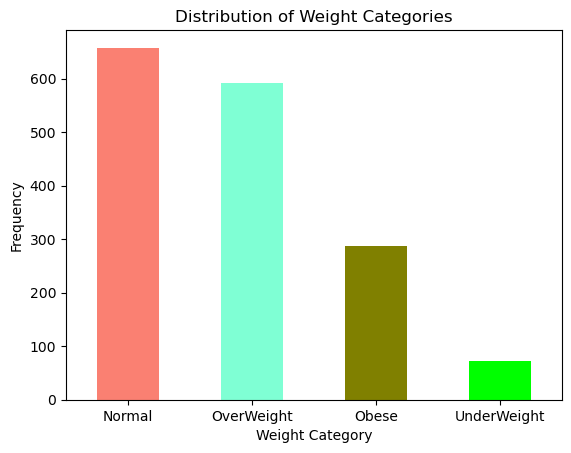

In [7]:
dc["Weight_Classifier"].value_counts().plot(kind = 'bar', color = ["salmon", "aquamarine", "olive", "lime"])
plt.xticks(rotation = 0)
plt.title("Distribution of Weight Categories")
plt.xlabel("Weight Category")
plt.ylabel("Frequency");

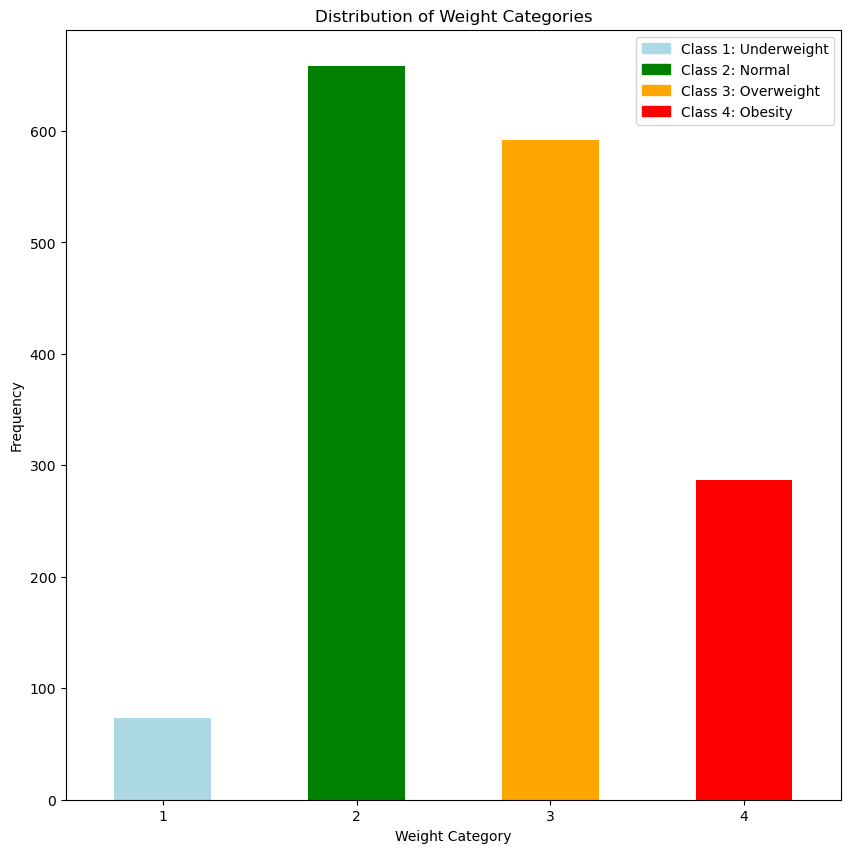

In [8]:
colors = ['lightblue', 'green', 'orange', 'red']

# Increase the plot size to make space for the legend
plt.figure(figsize=(10, 10))

# Plot the numeric class values with specified colors
data['Class'].value_counts().sort_index().plot(kind='bar', color=colors)
plt.xticks(rotation = 0)
plt.title("Distribution of Weight Categories")
plt.xlabel("Weight Category")
plt.ylabel("Frequency")
# Add a custom legend
class_labels = {1: 'Underweight', 2: 'Normal', 3: 'Overweight', 4: 'Obesity'}
legend_patches = [plt.Rectangle((0, 0), 1, 1, color=colors[i], label=f"Class {k}: {v}") for i, (k, v) in enumerate(class_labels.items())]
plt.legend(handles=legend_patches);

In [7]:
data.describe()

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Class
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1.557764,33.115528,167.741615,1.834783,1.729193,2.063354,1.872050,2.395652,1.69441,2.108696,1.822360,3.265839,2.012422,2.667081,2.678882
std,0.496806,9.835076,7.979873,0.371492,0.444515,0.746043,0.638345,1.010501,0.46080,0.814710,0.382328,1.343035,0.697929,1.518388,0.815855
min,1.000000,18.000000,150.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,25.000000,161.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.00000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000
50%,2.000000,32.000000,168.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,3.000000,2.000000,3.000000,3.000000
75%,2.000000,41.000000,174.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.00000,3.000000,2.000000,4.000000,2.000000,4.000000,3.000000
max,2.000000,54.000000,193.000000,2.000000,2.000000,3.000000,3.000000,4.000000,2.00000,3.000000,2.000000,5.000000,3.000000,5.000000,4.000000


In [8]:
data.Sex.value_counts()

Sex
2    898
1    712
Name: count, dtype: int64

.




We will compare the sex columns with the weight class columns

In [9]:
pd.crosstab(data.Class, data.Sex)

Sex,1,2
Class,,
1,14,59
2,188,470
3,358,234
4,152,135


In [10]:
pd.crosstab(dc.Weight_Classifier, data.Sex)

Sex,1,2
Weight_Classifier,,
Normal,188,470
Obese,152,135
OverWeight,358,234
UnderWeight,14,59


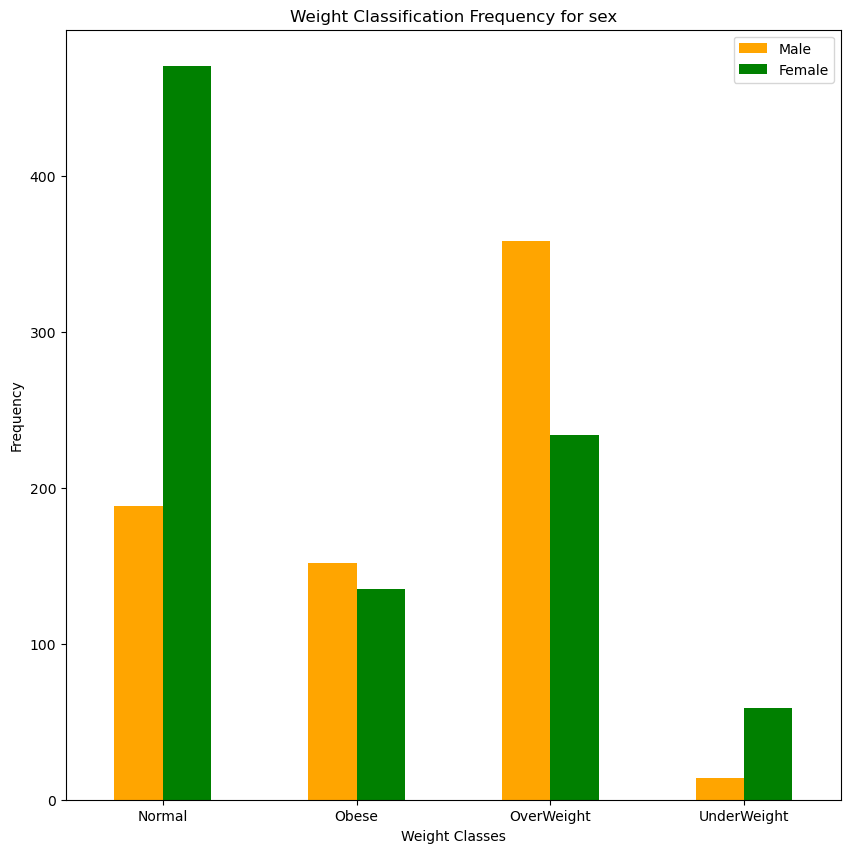

In [13]:
# Create a plot of crosstab
pd.crosstab(dc.Weight_Classifier, data.Sex).plot(kind = "bar",
                                                 figsize = (10, 10),
                                                 color = ['orange', 'green'])
plt.title("Weight Classification Frequency for sex")
plt.xlabel("Weight Classes")
plt.ylabel("Frequency")
plt.legend(["Male", "Female"]);
plt.xticks(rotation = 0);

.



Now we will try to compare the ages with the weight classifying class

In [11]:
data.Age.value_counts()

Age
23    80
25    78
21    76
26    74
20    70
22    64
24    56
29    52
27    52
39    52
30    50
32    50
33    50
35    48
41    46
37    46
28    44
42    44
31    40
45    40
43    40
34    40
36    38
38    38
40    36
46    34
44    32
19    30
47    30
48    28
51    26
52    24
54    22
50    22
49    22
18    20
53    16
Name: count, dtype: int64

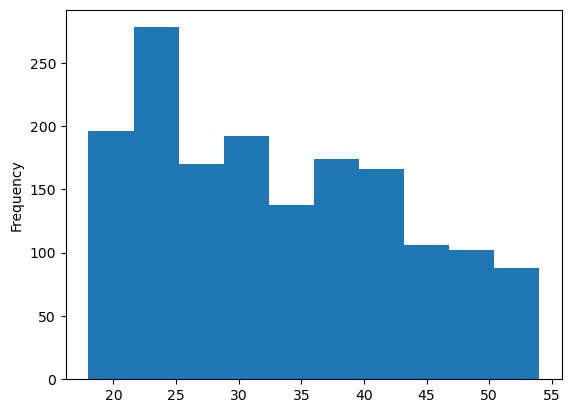

In [15]:
# We will plot the age on histogram 
data.Age.plot.hist();

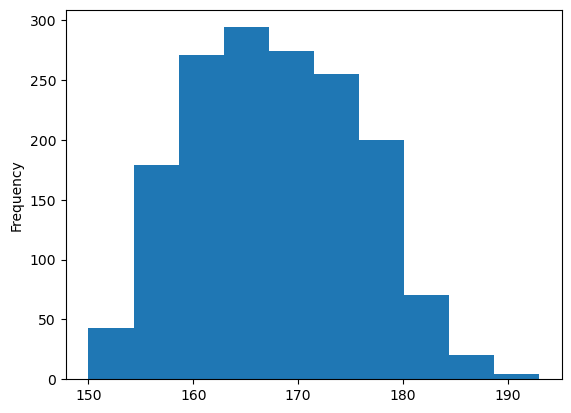

In [16]:
# ploting the height on the histogram
data.Height.plot.hist();

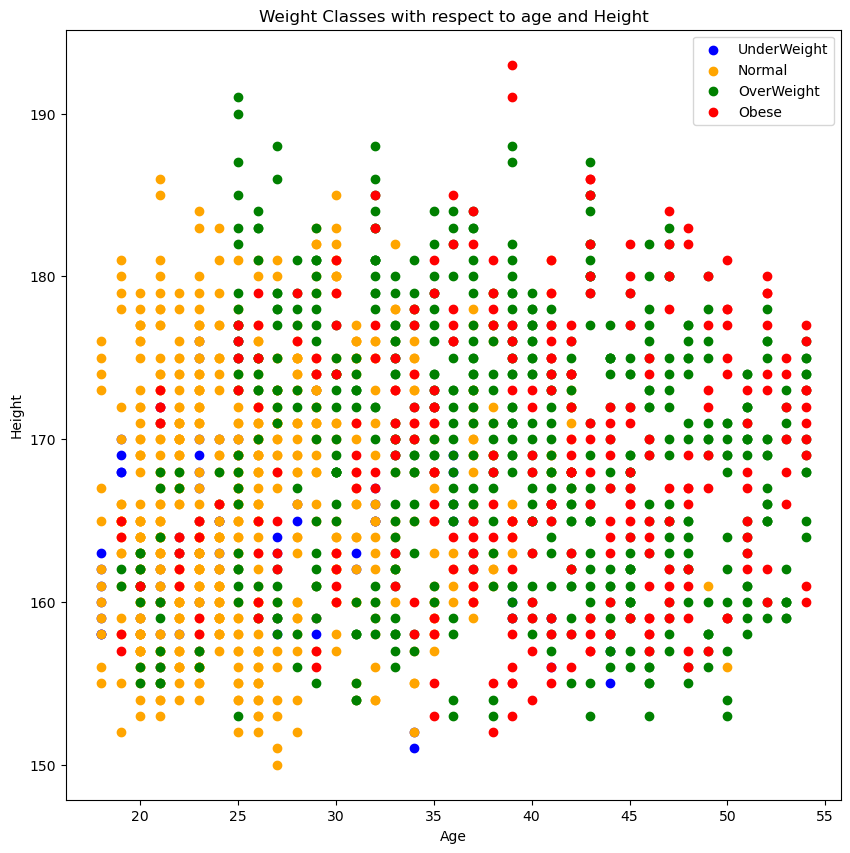

In [17]:
# Cause of the large categories of age and height, we will plot it using scatter plot against the weight classes
plt.figure(figsize = (10, 10))

# Scatter with underweight samples
plt.scatter(data.Age[data.Class == 1],
            data.Height[data.Class == 1],
            c = "blue",
            label = "UnderWeight")

# Scatter with Normal samples
plt.scatter(data.Age[data.Class == 2],
            data.Height[data.Class == 2],
            c = "orange",
            label = "Normal")

# Scatter with Overweight samples
plt.scatter(data.Age[data.Class == 3],
            data.Height[data.Class == 3],
            c = "green",
            label = "OverWeight")

# Scatter with Obese samples
plt.scatter(data.Age[data.Class == 4],
            data.Height[data.Class == 4],
            c = "red",
            label = "Obese")

# Add some helpful information 
plt.title("Weight Classes with respect to age and Height")
plt.xlabel("Age")
plt.ylabel("Height")
plt.legend();

...




We will plot the four different weight classes with their respective age groups

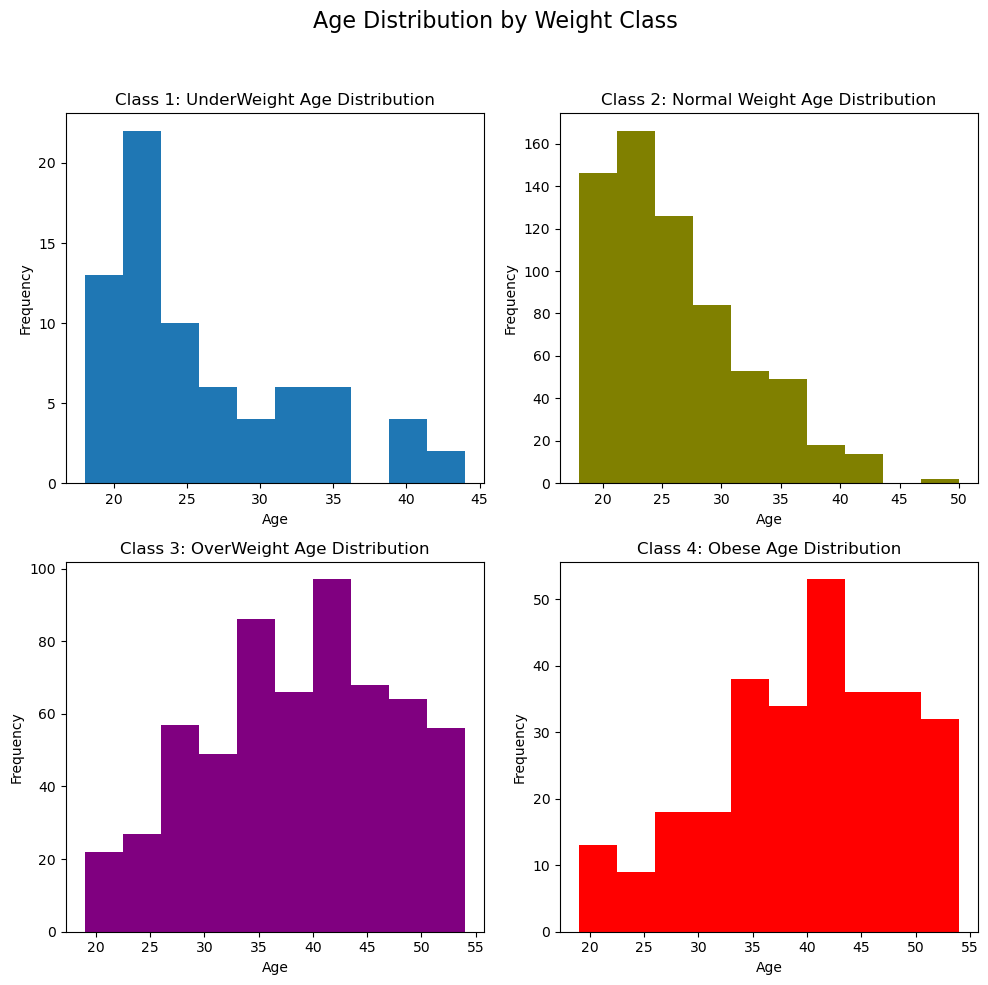

In [18]:
#subplot option 1
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows = 2,
                                            ncols = 2,
                                            figsize = (10, 10))

#plot to each different axis
ax1.hist(data.Age[data.Class == 1], color = "#1f77b4");
ax2.hist(data.Age[data.Class == 2], color = "olive");
ax3.hist(data.Age[data.Class == 3], color = "#800080");
ax4.hist(data.Age[data.Class == 4], color = "red");

# Add titles and labels for each axis
ax1.set_title('Class 1: UnderWeight Age Distribution')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')

ax2.set_title('Class 2: Normal Weight Age Distribution')
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')

ax3.set_title('Class 3: OverWeight Age Distribution')
ax3.set_xlabel('Age')
ax3.set_ylabel('Frequency')

ax4.set_title('Class 4: Obese Age Distribution')
ax4.set_xlabel('Age')
ax4.set_ylabel('Frequency')

# Add overall title for the figure
fig.suptitle('Age Distribution by Weight Class', fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95]);  # Adjust rect to make room for the title

...




We will plot the four different weight classes with their respective height groups

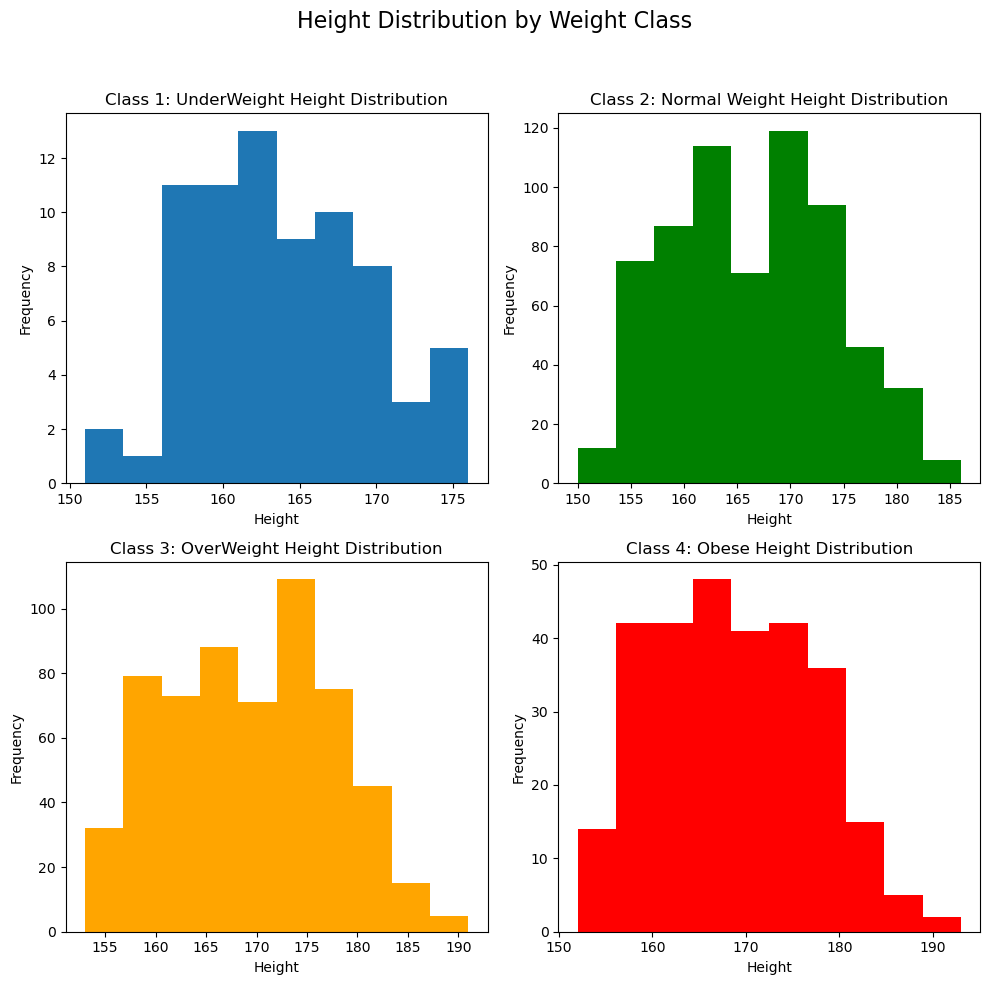

In [19]:
#subplot option 1
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows = 2,
                                            ncols = 2,
                                            figsize = (10, 10))

#plot to each different axis
ax1.hist(data.Height[data.Class == 1], color = "#1f77b4");
ax2.hist(data.Height[data.Class == 2], color = "green");
ax3.hist(data.Height[data.Class == 3], color = "orange");
ax4.hist(data.Height[data.Class == 4], color = "red");

# Add titles and labels for each axis
ax1.set_title('Class 1: UnderWeight Height Distribution')
ax1.set_xlabel('Height')
ax1.set_ylabel('Frequency')

ax2.set_title('Class 2: Normal Weight Height Distribution')
ax2.set_xlabel('Height')
ax2.set_ylabel('Frequency')

ax3.set_title('Class 3: OverWeight Height Distribution')
ax3.set_xlabel('Height')
ax3.set_ylabel('Frequency')

ax4.set_title('Class 4: Obese Height Distribution')
ax4.set_xlabel('Height')
ax4.set_ylabel('Frequency')

# Add overall title for the figure
fig.suptitle('Height Distribution by Weight Class', fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95]);  # Adjust rect to make room for the title

In [20]:
print(f"For the height columns the number of persons who are underweight:{data.Height[data.Class == 1].value_counts()}")

For the height columns the number of persons who are underweight:Height
158    7
163    7
165    7
159    6
160    5
168    4
166    4
170    4
169    4
162    4
156    2
176    2
161    2
157    2
167    2
164    2
175    2
152    1
172    1
171    1
173    1
174    1
151    1
155    1
Name: count, dtype: int64


In [21]:
print(f"For the height columns the number of persons who are Normal weight:{data.Height[data.Class == 2].value_counts()}")
       

For the height columns the number of persons who are Normal weight:Height
160    37
171    35
165    32
164    32
170    30
162    29
169    29
173    29
175    28
163    28
159    27
166    25
157    25
161    25
168    25
158    23
156    20
174    19
172    18
176    18
177    17
155    16
167    14
154    14
178    11
179    10
181     9
180     9
153     5
152     5
183     4
182     4
185     2
151     1
186     1
184     1
150     1
Name: count, dtype: int64


In [22]:
print(f"For the height columns the number of persons who are overweight:{data.Height[data.Class == 3].value_counts()}")

For the height columns the number of persons who are overweight:Height
175    30
168    29
174    29
165    27
169    27
170    27
172    25
173    25
160    24
161    24
177    23
162    23
159    22
158    21
176    19
179    18
171    17
166    17
163    17
167    15
178    15
180    14
181    13
157    12
156    11
183    10
155    10
164     9
182     8
184     6
153     6
154     5
185     4
187     3
188     3
186     2
191     1
190     1
Name: count, dtype: int64


In [23]:
print(f"For the height columns the number of persons who are Obese: {data.Height[data.Class == 4].value_counts()}")

For the height columns the number of persons who are Obese: Height
177    15
165    15
168    14
159    14
173    13
172    13
175    11
163    11
164    11
158    11
162    11
166    10
169    10
171    10
179    10
174    10
161     9
167     9
160     9
176     8
170     8
157     8
178     6
182     6
180     5
155     5
156     5
181     5
185     3
153     2
183     2
184     2
186     2
152     1
191     1
154     1
193     1
Name: count, dtype: int64


In [24]:
print(f"For the Age columns the number of persons who are UnderWeight: {data.Age[data.Class == 1].value_counts()}")

For the Age columns the number of persons who are UnderWeight: Age
23    10
21     8
18     7
24     6
19     4
32     4
27     4
22     4
36     4
29     4
25     4
20     2
28     2
31     2
34     2
39     2
41     2
44     2
Name: count, dtype: int64


In [25]:
print(f"For the Age columns the number of persons who are Normal Weight: {data.Age[data.Class == 2].value_counts()}")

For the Age columns the number of persons who are Normal Weight: Age
23    64
20    58
21    55
26    54
22    54
24    48
25    46
28    31
30    27
29    26
27    26
31    21
19    20
32    19
37    16
34    15
35    14
18    13
33    13
38    12
42     8
39     6
41     6
36     4
50     1
49     1
Name: count, dtype: int64


In [26]:
print(f"For the Age columns the number of persons who are OverWeight: {data.Age[data.Class == 3].value_counts()}")

For the Age columns the number of persons who are OverWeight: Age
33    29
39    28
45    27
43    26
40    26
25    24
41    23
42    22
36    22
37    22
32    21
46    21
47    20
35    20
44    20
29    18
51    18
27    18
48    17
52    16
38    16
30    15
34    15
49    14
31    13
50    13
26    12
54    12
53    10
21     9
28     9
20     9
22     2
19     2
23     2
24     1
Name: count, dtype: int64


In [27]:
print(f"For the Age columns the number of persons who are Obese: {data.Age[data.Class == 4].value_counts()}")

For the Age columns the number of persons who are Obese: Age
39    16
41    15
42    14
43    14
35    14
46    13
45    13
48    11
54    10
40    10
44    10
38    10
47    10
30     8
37     8
26     8
52     8
36     8
50     8
34     8
51     8
33     8
49     7
53     6
32     6
22     4
29     4
23     4
19     4
31     4
25     4
27     4
21     4
28     2
20     1
24     1
Name: count, dtype: int64


In [12]:
pd.crosstab(dc.Weight_Classifier, data.Overweight_Obese_Family)

Overweight_Obese_Family,1,2
Weight_Classifier,,
Normal,53,605
Obese,122,165
OverWeight,85,507
UnderWeight,6,67


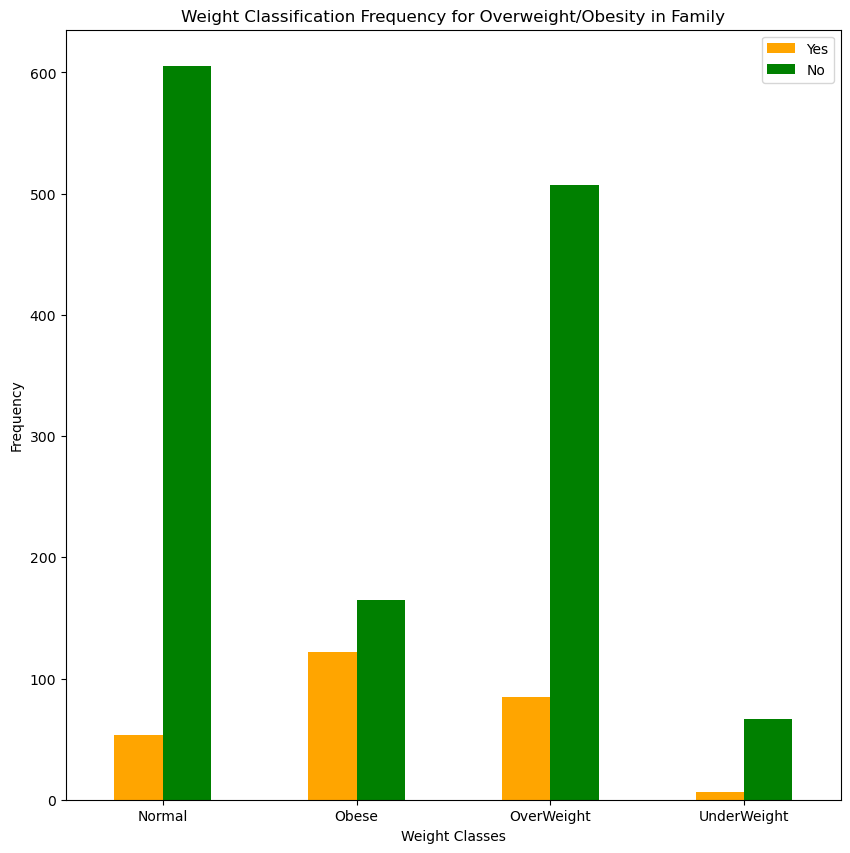

In [29]:
pd.crosstab(dc.Weight_Classifier, data.Overweight_Obese_Family).plot(kind = "bar",
                                                                     figsize = (10, 10),
                                                                     color = ['orange', 'green'])
plt.title("Weight Classification Frequency for Overweight/Obesity in Family")
plt.xlabel("Weight Classes")
plt.ylabel("Frequency")
plt.legend(["Yes", "No"]);
plt.xticks(rotation = 0);

In [13]:
pd.crosstab(dc.Weight_Classifier, data.Consumption_of_Fast_Food)

Consumption_of_Fast_Food,1,2
Weight_Classifier,,
Normal,65,593
Obese,163,124
OverWeight,200,392
UnderWeight,8,65


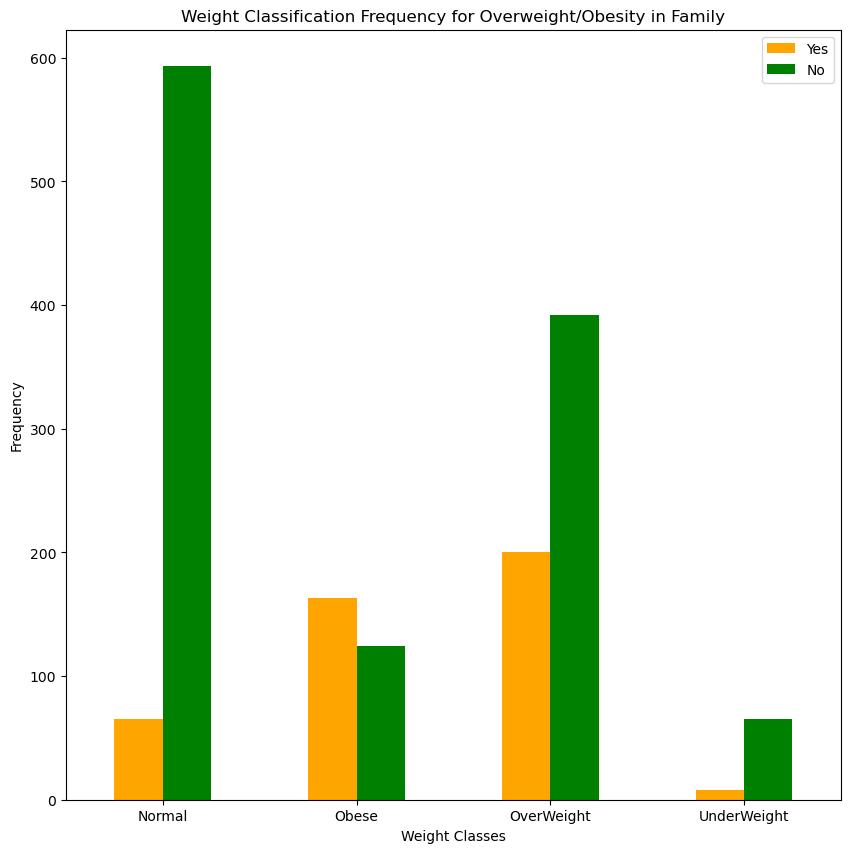

In [31]:
pd.crosstab(dc.Weight_Classifier, data.Consumption_of_Fast_Food).plot(kind = "bar",
                                                                     figsize = (10, 10),
                                                                     color = ['orange', 'green'])
plt.title("Weight Classification Frequency for Overweight/Obesity in Family")
plt.xlabel("Weight Classes")
plt.ylabel("Frequency")
plt.legend(["Yes", "No"]);
plt.xticks(rotation = 0);

In [5]:
data.corr()

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Class
Sex,1.000000,-0.182114,-0.690250,0.068580,0.059621,0.146067,0.044877,-0.011508,0.196608,0.012885,-0.027745,-0.086369,-0.005656,0.028805,-0.252446
Age,-0.182114,1.000000,0.115491,-0.161475,-0.272612,-0.394701,0.328642,0.047053,-0.077778,0.026510,-0.203458,0.337484,-0.254816,-0.689950,0.579812
Height,-0.690250,0.115491,1.000000,-0.165359,-0.031478,-0.090057,-0.055054,-0.000186,-0.141490,-0.026460,-0.029721,0.076698,0.001916,-0.003872,0.161563
Overweight_Obese_Family,0.068580,-0.161475,-0.165359,1.000000,0.255797,0.244100,-0.183549,-0.012842,0.213165,0.071693,0.274573,-0.166033,0.094216,0.098551,-0.292041
Consumption_of_Fast_Food,0.059621,-0.272612,-0.031478,0.255797,1.000000,0.340379,-0.336837,-0.022824,0.238982,0.052156,0.265310,-0.322823,0.050916,0.183102,-0.380463
Frequency_of_Consuming_Vegetables,0.146067,-0.394701,-0.090057,0.244100,0.340379,1.000000,-0.400581,-0.022553,0.143130,0.026497,0.205080,-0.263694,0.099946,0.234800,-0.544496
Number_of_Main_Meals_Daily,0.044877,0.328642,-0.055054,-0.183549,-0.336837,-0.400581,1.000000,0.109361,-0.107655,0.041099,-0.195050,0.226734,-0.064786,-0.240188,0.509390
Food_Intake_Between_Meals,-0.011508,0.047053,-0.000186,-0.012842,-0.022824,-0.022553,0.109361,1.000000,-0.035156,0.002084,0.014730,-0.004277,-0.036054,-0.035212,0.129327
Smoking,0.196608,-0.077778,-0.141490,0.213165,0.238982,0.143130,-0.107655,-0.035156,1.000000,0.065356,0.122064,-0.089587,0.040799,0.017947,-0.178526
Liquid_Intake_Daily,0.012885,0.026510,-0.026460,0.071693,0.052156,0.026497,0.041099,0.002084,0.065356,1.000000,0.048060,0.019584,-0.035167,-0.007907,-0.031608


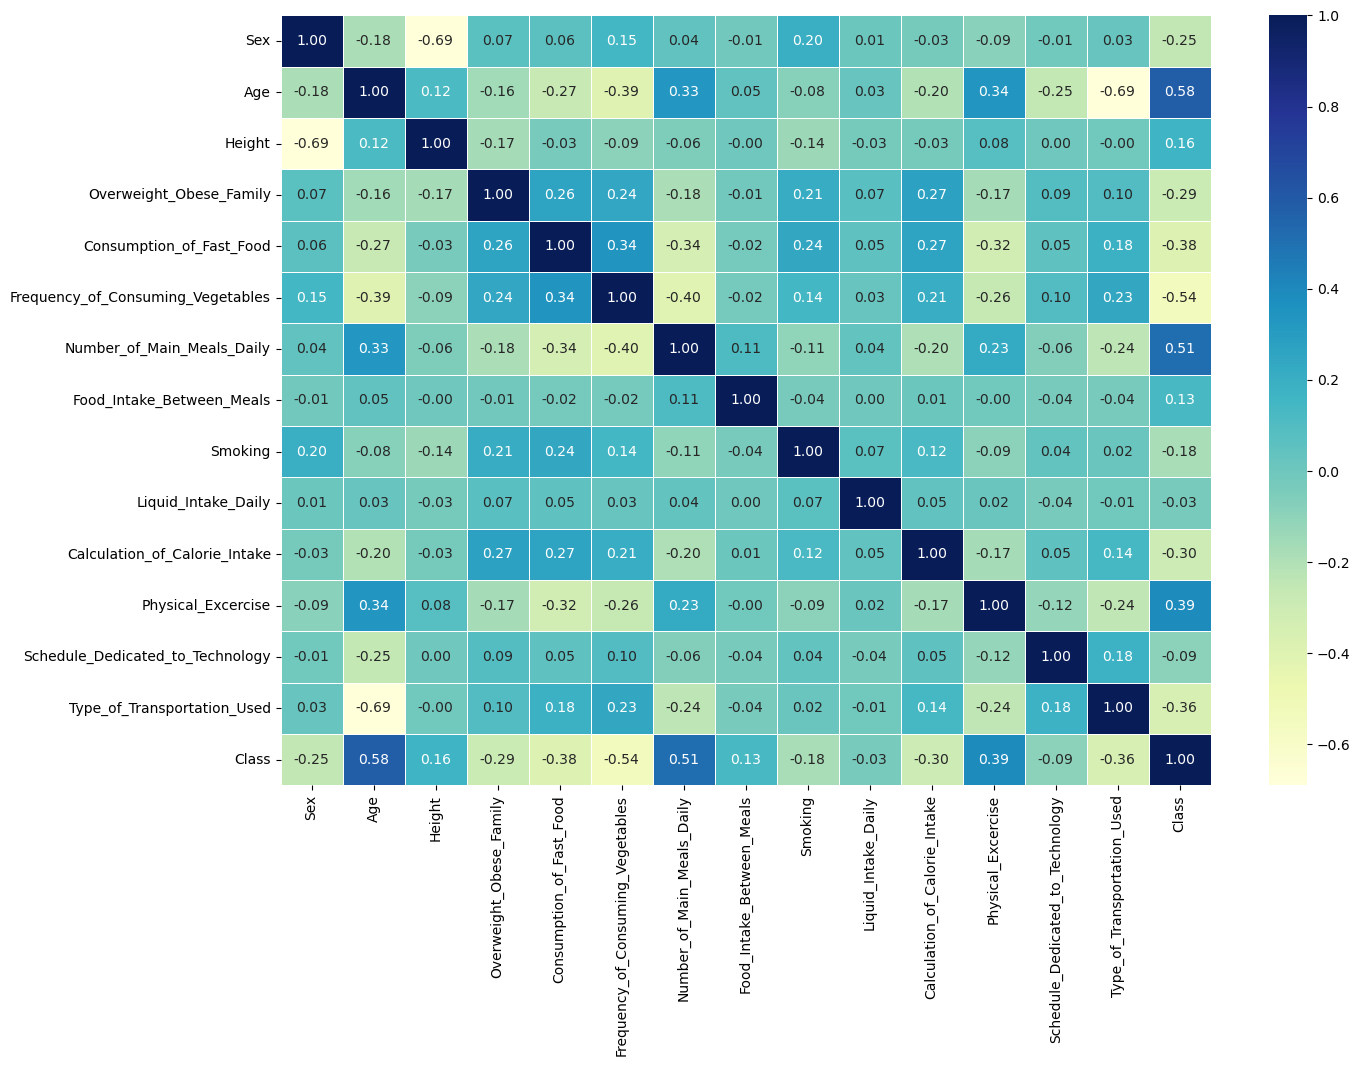

In [6]:
# let's make our correlation matrix a little prettier
corr_matrix = data.corr()
fig, ax = plt.subplots(figsize = (15, 10))
ax = sns.heatmap(corr_matrix,
                 annot = True,
                 linewidths = 0.5,
                 fmt = ".2f",
                 cmap = "YlGnBu"); # YlGnBu = Yellow Green Blue

## Modelling

In [25]:
data

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Class
0,2,18,155,2,2,3,1,3,2,1,2,3,3,4,2
1,2,18,158,2,2,3,1,1,2,1,2,1,3,3,2
2,2,18,159,2,2,2,1,3,2,3,2,2,3,4,2
3,2,18,162,2,2,2,2,2,2,2,2,1,3,4,2
4,2,18,165,2,1,2,1,3,2,1,2,3,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,2,51,165,2,1,1,3,4,1,3,1,3,1,1,4
1606,2,51,163,2,1,2,2,4,2,2,2,5,1,1,4
1607,2,52,162,1,2,1,3,4,1,3,1,4,1,1,4
1608,2,53,168,2,1,1,3,4,1,2,2,2,1,1,4


In [7]:
x = data.drop("Class", axis = 1)
y = data.Class

In [9]:
x

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used
0,2,18,155,2,2,3,1,3,2,1,2,3,3,4
1,2,18,158,2,2,3,1,1,2,1,2,1,3,3
2,2,18,159,2,2,2,1,3,2,3,2,2,3,4
3,2,18,162,2,2,2,2,2,2,2,2,1,3,4
4,2,18,165,2,1,2,1,3,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,2,51,165,2,1,1,3,4,1,3,1,3,1,1
1606,2,51,163,2,1,2,2,4,2,2,2,5,1,1
1607,2,52,162,1,2,1,3,4,1,3,1,4,1,1
1608,2,53,168,2,1,1,3,4,1,2,2,2,1,1


In [10]:
y

0       2
1       2
2       2
3       2
4       2
       ..
1605    4
1606    4
1607    4
1608    4
1609    4
Name: Class, Length: 1610, dtype: int64

In [8]:
# Split the data into test and training set
np.random.seed(42)

x_train, x_test, y_train, y_test = train_test_split(x, 
                                                    y, 
                                                    test_size = 0.2)

In [19]:
x_train

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used
1406,1,44,174,2,2,2,2,2,1,3,2,1,1,1
707,1,49,177,2,2,2,2,4,1,2,1,4,3,1
966,2,26,161,2,2,2,2,2,2,3,2,2,2,2
601,1,44,175,2,2,2,2,2,1,2,2,1,1,1
350,2,49,157,2,2,2,2,2,2,1,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,2,45,160,2,2,2,1,2,2,3,2,4,1,1
1294,1,31,176,2,2,3,1,3,2,1,2,1,2,1
860,2,21,162,2,2,3,1,1,2,2,2,1,3,3
1459,1,28,179,1,1,2,2,2,2,3,1,5,1,4


In [20]:
x_test

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used
29,2,20,161,2,1,2,2,3,2,2,2,1,2,1
99,2,23,161,2,2,3,1,3,2,1,2,3,2,5
678,1,39,173,1,1,2,2,3,2,1,1,5,2,1
1399,1,43,181,2,1,2,2,3,2,1,2,4,1,1
185,2,28,158,2,2,2,2,2,2,3,2,2,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
617,1,47,169,2,1,1,2,2,2,1,2,5,1,1
629,1,49,178,1,1,1,2,2,1,1,1,3,2,1
1574,2,35,159,1,2,1,3,3,2,3,2,5,3,5
1323,1,34,173,2,2,2,2,2,2,1,2,1,1,1


In [21]:
y_test

29      4
99      2
678     4
1399    3
185     3
       ..
617     3
629     3
1574    4
1323    2
948     2
Name: Class, Length: 322, dtype: int64

In [22]:
y_train

1406    3
707     4
966     2
601     3
350     3
       ..
1130    3
1294    2
860     2
1459    4
1126    3
Name: Class, Length: 1288, dtype: int64

...

Now we've got our data split into training and test sets, it's time to build a machine learning model.

We'll train it (find the patterns) on the training set.

And we'll test it (use the patterns) on the test set

We're going to try 3 different machine learning models:
1. Logistic Regression
2. K-Nearest Neighbours classifiers
3. Random Forest Classifier
4. Linear SVC
5. SVC

In [9]:
%%time
# Put models in a dictionary
models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier(),
          "LinearSVC": LinearSVC(),
          "SVC": SVC()}

# Create a function to fit and score models
def fit_and_score(models, x_train, x_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different scikit-learn machine learning models
    x_train : training data (no labels)
    x_test : testing data (no labels)
    y_train : training labels 
    y_test : test labels
    """
    
    # Set random seed
    np.random.seed(42)
    
    # Make dictionary to keep model scores
    model_scores = {}
    
    # LOOP through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(x_train, y_train)
        # Evaluate the model and append its score to the model_scores
        model_scores[name] = model.score(x_test, y_test)
    
    return model_scores


CPU times: total: 0 ns
Wall time: 1 ms


In [10]:
%%time
model_scores = fit_and_score(models = models,
                             x_train = x_train,
                             x_test = x_test,
                             y_train = y_train,
                             y_test = y_test)
model_scores

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CPU times: total: 2.36 s
Wall time: 13.8 s


{'Logistic Regression': 0.7142857142857143,
 'KNN': 0.6677018633540373,
 'Random Forest': 0.8509316770186336,
 'LinearSVC': 0.717391304347826,
 'SVC': 0.6428571428571429}

### Model Comparison

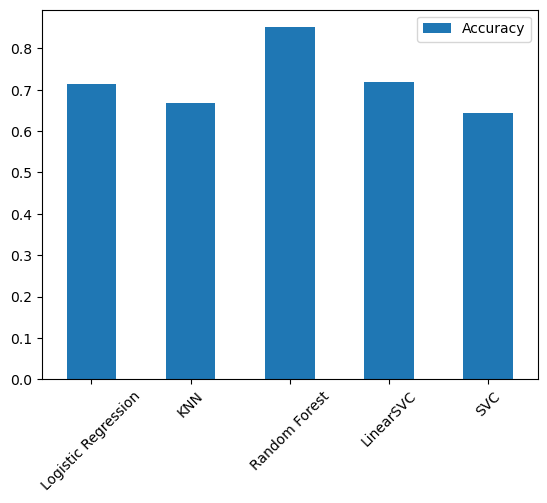

In [30]:
model_compare = pd.DataFrame(model_scores, index = ["Accuracy"])
# The T in the code below is to transpose the plot
model_compare.T.plot.bar()
plt.xticks(rotation = 45);

...

Now we've got a baseline mode... and we know our model's first predictions aren't always what we 
should base our next steps off. what should we do?

let's look at the following:
* Hyperparameter tuning
* Feature importance
* Confusion matrix
* Cross-validation
* Precision
* Recall
* F1 score
* Classification report
* ROC curve
* Area under the curve (AUC)

### Hyperparameter tuning by hand

#### Tuning the KNN model

In [15]:
# Tuning the KNN model
train_score = {}
test_score = {}
n_neighbors = np.arange(1, 50, 1)
for neighbor in n_neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(x_train, y_train)
    train_score[neighbor]=knn.score(x_train, y_train)
    test_score[neighbor]=knn.score(x_test, y_test)

In [16]:
train_score

{1: 1.0,
 2: 0.8843167701863354,
 3: 0.8998447204968945,
 4: 0.8167701863354038,
 5: 0.782608695652174,
 6: 0.7600931677018633,
 7: 0.7639751552795031,
 8: 0.7406832298136646,
 9: 0.7360248447204969,
 10: 0.71972049689441,
 11: 0.7135093167701864,
 12: 0.6972049689440993,
 13: 0.702639751552795,
 14: 0.6855590062111802,
 15: 0.6801242236024845,
 16: 0.6770186335403726,
 17: 0.6684782608695652,
 18: 0.6692546583850931,
 19: 0.671583850931677,
 20: 0.6692546583850931,
 21: 0.6645962732919255,
 22: 0.6607142857142857,
 23: 0.6614906832298136,
 24: 0.656055900621118,
 25: 0.656832298136646,
 26: 0.6537267080745341,
 27: 0.65527950310559,
 28: 0.6537267080745341,
 29: 0.6545031055900621,
 30: 0.6521739130434783,
 31: 0.6482919254658385,
 32: 0.6451863354037267,
 33: 0.6444099378881988,
 34: 0.6444099378881988,
 35: 0.640527950310559,
 36: 0.6413043478260869,
 37: 0.6389751552795031,
 38: 0.6296583850931677,
 39: 0.6312111801242236,
 40: 0.6265527950310559,
 41: 0.6288819875776398,
 42: 0.62

In [17]:
test_score

{1: 0.7981366459627329,
 2: 0.717391304347826,
 3: 0.6832298136645962,
 4: 0.6490683229813664,
 5: 0.6677018633540373,
 6: 0.6614906832298136,
 7: 0.6770186335403726,
 8: 0.6521739130434783,
 9: 0.65527950310559,
 10: 0.6583850931677019,
 11: 0.6614906832298136,
 12: 0.6521739130434783,
 13: 0.6677018633540373,
 14: 0.6490683229813664,
 15: 0.6459627329192547,
 16: 0.6490683229813664,
 17: 0.6335403726708074,
 18: 0.6583850931677019,
 19: 0.6459627329192547,
 20: 0.6677018633540373,
 21: 0.65527950310559,
 22: 0.6739130434782609,
 23: 0.6645962732919255,
 24: 0.6614906832298136,
 25: 0.6708074534161491,
 26: 0.65527950310559,
 27: 0.6739130434782609,
 28: 0.6801242236024845,
 29: 0.6832298136645962,
 30: 0.6739130434782609,
 31: 0.6708074534161491,
 32: 0.6770186335403726,
 33: 0.6677018633540373,
 34: 0.6801242236024845,
 35: 0.6739130434782609,
 36: 0.6677018633540373,
 37: 0.6645962732919255,
 38: 0.65527950310559,
 39: 0.6645962732919255,
 40: 0.6614906832298136,
 41: 0.64906832298

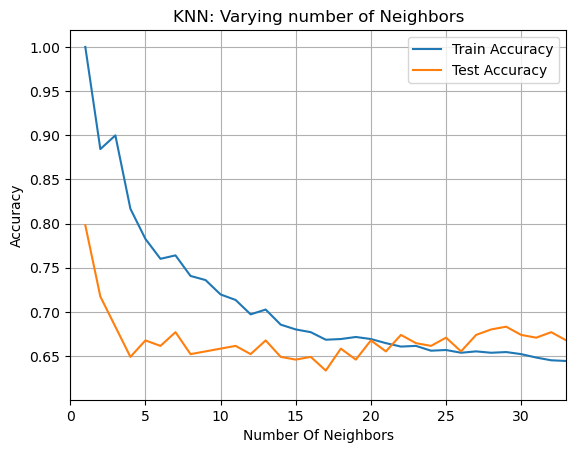

In [18]:
plt.plot(n_neighbors, train_score.values(), label="Train Accuracy")
plt.plot(n_neighbors, test_score.values(), label="Test Accuracy")
plt.xlabel("Number Of Neighbors")
plt.ylabel("Accuracy")
plt.title("KNN: Varying number of Neighbors")
plt.legend()
plt.xlim(0, 33)
# plt.ylim(0.60, 0.9)
plt.grid()
plt.show();

In [19]:
# Finding the best test scores
for key, value in test_score.items():
    if value==max(test_score.values()):
        print(key)

1



.....


We will use GridSearchCV to find the best params

In [31]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import accuracy_score

In [21]:
%%time
kf=KFold(n_splits=5,shuffle=True,random_state=42)
parameter={'n_neighbors': np.arange(1, 51, 1)}
knn=KNeighborsClassifier()
knn_cv=GridSearchCV(knn, param_grid=parameter, cv=kf, verbose=1)
knn_cv.fit(x_train, y_train)
print(knn_cv.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'n_neighbors': 1}
CPU times: total: 17.5 s
Wall time: 25.7 s


In [22]:
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)
y_pred=knn.predict(x_test)
accuracy_score = accuracy_score(y_test, y_pred)*100
print(f"Accuracy for testing dataset after tuning : {accuracy_score:.2f}")

Accuracy for testing dataset after tuning : 79.81


#### Tuning the Logistic Regression Model

Common Hyperparameters for Logistic Regression

* C: The regularization strength. Smaller values specify stronger regularization (penalizing large coefficients). Larger values mean weaker regularization (less penalty on large coefficients).

* penalty: The regularization type. Common choices are 'l1', 'l2', and 'elasticnet'.

* solver: The optimization algorithm used. Common solvers include:
'newton-cg', 'lbfgs', 'liblinear', 'saga' (for L1, L2, and ElasticNet penalties)


   **Not all solvers support all types of penalties:**
     * `'liblinear'` solver supports both `'l1'` and `'l2'` penalties.
     * `'newton-cg'`, `'lbfgs'`, and `'saga'` solvers support only the `'l2'` penalty.
     * `'saga'` solver supports both `'l1'` and `'l2'` penalties.

* max_iter: The maximum number of iterations for the solver to converge.

* fit_intercept: Whether to include an intercept (bias) term in the model.

* class_weight: Weights associated with classes. This is useful for imbalanced datasets.

* tol: Tolerance for stopping criteria. Smaller values may result in more iterations but higher accuracy.

In [11]:
LogisticRegression().get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [12]:
%%time
log_param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],  # Removed 'none'
    'C': np.logspace(-4, 4, 20),
    'solver': ['liblinear', 'saga'],  # Removed unsupported solvers for 'l1' and 'elasticnet'
    'max_iter': [100, 1000, 2500, 5000],
    'l1_ratio': [0.1, 0.5, 0.7]  # Added for 'elasticnet' penalty
}

CPU times: total: 0 ns
Wall time: 0 ns


In [13]:
# Define the hyperparameter grid for penalty and solver
log_reg_grid = {
                'logisticregression__C': np.logspace(-4, 4, 30),
                'logisticregression__penalty': ['l2'],
                'logisticregression__solver': ['newton-cg', 'lbfgs', 'liblinear'],
                'logisticregression__class_weight': [None, 'balanced'],
                'logisticregression__max_iter': [1000, 2500, 5000]
               }

In [14]:
%%time
# Tune LogisticRegression

np.random.seed(42)

# Setup GridSearchCV hyperparameter search for LogisticRegression
GS_log_reg = GridSearchCV(LogisticRegression(),
                               param_grid = log_param_grid,
                               cv = 3,
                               verbose = True,
                               n_jobs = -1)

# Fit random hyperparameter search model for LogisticRegression
GS_log_reg.fit(x_train, y_train)


Fitting 3 folds for each of 1440 candidates, totalling 4320 fits


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
720 fits failed out of a total of 4320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
720 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _

CPU times: total: 29.9 s
Wall time: 21h 35min 36s


GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'l1_ratio': [0.1, 0.5, 0.7],
                         'max_iter': [100, 1000, 2500, 5000],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['liblinear', 'saga']},
             verbose=True)

In [15]:
GS_log_reg.best_params_

{'C': 29.763514416313132,
 'l1_ratio': 0.1,
 'max_iter': 2500,
 'penalty': 'l1',
 'solver': 'liblinear'}

In [16]:
GS_log_reg.score(x_test, y_test)

0.7298136645962733

In [17]:
np.random.seed(42)
gs_log_reg = LogisticRegression(C = 29.763514416313132,
                                l1_ratio = 0.1,
                                max_iter = 2500,
                                penalty = 'l1',
                                solver = 'liblinear')

In [18]:
np.random.seed(42)
gs_log_reg.fit(x_train, y_train)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


LogisticRegression(C=29.763514416313132, l1_ratio=0.1, max_iter=2500,
                   penalty='l1', solver='liblinear')

In [19]:
np.random.seed(42)
gs_log_reg.score(x_test, y_test)

0.7298136645962733

In [ ]:
np.logspace(-4, 4, 20)

In [ ]:
np.logspace(-4, 4, 50)

> We will try another hyperparamete tuning of Logistic Regression Model, using the L2 penalty

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [22]:
# Create a pipeline with StandardScaler and LogisticRegression
log_reg = make_pipeline(StandardScaler(), LogisticRegression())

# Setup grid hyperparameter search for LogisticRegression
log_reg_mod = GridSearchCV(log_reg,
                          param_grid = log_reg_grid,
                          cv = 5,
                          verbose = True)

In [23]:
%%time
log_reg_mod.fit(x_train, y_train)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
CPU times: total: 3min 55s
Wall time: 15min 47s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2...
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'logisticregression__class_weight': [None, 'balanced'],
                         'logisticregression__max_iter': [1000, 2500, 5000],
                         'logisticregression__penalty': ['l2'],
                         'logisticregression__solver': ['newton-cg', 'lbfgs',
                                                        'liblinear']},
             verbose=True)

In [24]:
log_reg_mod.best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=17.433288221999874, max_iter=1000,
                                    solver='liblinear'))])

In [25]:
log_reg_mod.best_params_

{'logisticregression__C': 17.433288221999874,
 'logisticregression__class_weight': None,
 'logisticregression__max_iter': 1000,
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

In [26]:
bst_par = log_reg_mod.best_estimator_

bst_par.score(x_test, y_test)

0.7267080745341615

In [27]:
Log_regs = LogisticRegression(
    C = 17.433288221999874,
    class_weight = None,
    max_iter = 1000,
    penalty = 'l2',
    solver = 'liblinear'
)

In [28]:
Log_regs.fit(x_train, y_train)

LogisticRegression(C=17.433288221999874, max_iter=1000, solver='liblinear')

In [29]:
Log_regs.score(x_test, y_test)

0.7298136645962733

#### Tuning the LINEAR SVC model

To improve your LinearSVC model, you can tune the following parameters. Here's a breakdown of key hyperparameters and how you can alter them to potentially improve your model, along with suggested values:

1. C (Regularization Strength)
    * Current Value: `1.0`
    * Description: Controls the trade-off between achieving a low error on training data and minimizing model complexity. Smaller values of C encourage more regularization, preventing overfitting, while larger values reduce regularization and allow the model to fit better to the training data.
    * Tuning Suggestion: Try smaller or larger values depending on whether the model overfits or underfits.
Suggested values:`0.001`, `0.01`, `0.1`, `1`, `10`, `100`
    * Impact: Increasing C can reduce regularization and improve fit on the training set but may lead to overfitting. Decreasing C increases regularization, reducing the likelihood of overfitting but may also reduce accuracy.

2. class_weight
    * Current Value: `None`
    * Description: Handles class imbalance by assigning weights to classes. None means all classes are treated equally.
    * Tuning Suggestion: If you have class imbalance, try class_weight =`'balanced'`.
    * Impact: Helps in cases where some classes have significantly fewer samples than others by penalizing misclassifications more heavily on under-represented classes.

3. dual
    * Current Value: `'warn'` (older versions of sklearn, now defaults to False for penalty = `'l2'`)
    * Description: Determines the algorithm used to solve the optimization problem. For penalty = `'l2'` and when n_samples > n_features, setting dual=False is more efficient.
    * Tuning Suggestion: Use dual = `False` for large datasets where the number of samples is greater than the number of features.
    * Impact: This can improve the training speed.

4. max_iter
    * Current Value: `1000`
    * Description: The maximum number of iterations for the optimization algorithm.
    * Tuning Suggestion: If your model is not converging, you may need to increase this value.
    * Suggested values: `2000`, `3000`, `5000`.
    * Impact: Increasing max_iter can allow the model to converge fully if the current setting causes it to stop prematurely.

5. multi_class
    * Current Value: `'ovr'` (One-vs-Rest)
    * Description: Defines how the model handles multi-class classification problems. `'ovr'` means one binary classifier per class, while `'crammer_singer'` builds a single optimization problem.
    * Tuning Suggestion: The `'crammer_singer'` strategy can be tried if you want to optimize the entire dataset in a single problem.
    * Impact: `'ovr'` is faster and generally works well, while `'crammer_singer'` is more complex but may improve performance for certain datasets.

6. tol (Tolerance for stopping criteria)
    * Current Value: `0.0001`
    * Description: This defines the stopping criteria. Lower values mean the model will continue to try to converge for longer.
    * Tuning Suggestion: Reduce tolerance to allow more precise convergence.
    * Suggested values: `0.001`, `0.00001`, `0.000001`
    * Impact: Reducing tolerance can improve the accuracy by forcing the optimization to find a better solution but may increase training time.

7. fit_intercept
    * Current Value: `True`
    * Description: Specifies whether to calculate the intercept for this model.
    * Tuning Suggestion: This parameter is often left as True unless you have reason to believe that your data is already centered.
    * Impact: Little effect unless your data is already centered, in which case setting it to False can improve efficiency.


##### Suggested Parameter Tuning Strategy
**Regularization Strength (C):**
* Start by testing different values of C (like `0.1`, `1`, `10`) to see how the model behaves with less or more regularization.

**Class Weight (class_weight):**
* If you have imbalanced classes, set class_weight=`'balanced'` to adjust for it.

**Iteration Limit (max_iter):**
* Increase max_iter to make sure the model has enough time to converge. Start with `2000` or `3000`.

**Tolerance (tol):**
* Set tol to smaller values like `0.00001` if you want the model to converge more precisely.

**Dual Solver (dual):**
* Set dual=`False` if your dataset has more samples than features for better efficiency.

**Multi-Class Handling (multi_class):**
* Stick with `'ovr'`, unless you're curious to see if `'crammer_singer'` yields better results on your dataset.

In [30]:
LinearSVC().get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': 'auto',
 'fit_intercept': True,
 'intercept_scaling': 1,
 'loss': 'squared_hinge',
 'max_iter': 1000,
 'multi_class': 'ovr',
 'penalty': 'l2',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [33]:
linSVC_params = { 'C' : np.logspace(-4, 4, 10),
                     'penalty' : ['l1'],
                     'loss' : ['squared_hinge', 'hinge'],
                     'multi_class' : ['ovr','crammer_singer'],
                     'tol' : np.logspace(-4, 4, 10),
                     'class_weight' : ['balanced', None],
                     'dual' : [False]
                    }

In [32]:
%%time
# Tune LogisticRegression

np.random.seed(42)

# Setup GridSearchCV hyperparameter search for LogisticRegression
GS_lin_svcI = GridSearchCV(LinearSVC(),
                           param_grid = linSVC_params,
                           cv = 3,
                           verbose = True)

# Fit random hyperparameter search model for LogisticRegression
GS_lin_svcI.fit(x_train, y_train)


Fitting 3 folds for each of 3200 candidates, totalling 9600 fits


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of ite

In [ ]:
GS_lin_svcI.best_params_

In [ ]:
GS_lin_svcI.score(x_test, y_test)

In [68]:
linSVC_paramsI = { 'C' : np.logspace(-4, 4, 10),
                     'penalty' : ['l2'],
                     'loss' : ['squared_hinge', 'hinge'],
                     'multi_class' : ['ovr','crammer_singer'],
                     'tol' : np.logspace(-4, 4, 10),
                     'class_weight' : ['balanced', None],
                     'dual' : [True, False]
                    }

In [69]:
%%time
# Tune LogisticRegression

np.random.seed(42)

# Setup GridSearchCV hyperparameter search for LogisticRegression
GS_lin_svcII = GridSearchCV(LinearSVC(),
                           param_grid = linSVC_paramsI,
                           cv = 3,
                           verbose = True,
                           n_jobs = -1)

# Fit random hyperparameter search model for LogisticRegression
GS_lin_svcII.fit(x_train, y_train)


Fitting 3 folds for each of 1600 candidates, totalling 4800 fits


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
600 fits failed out of a total of 4800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
600 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_classes.py", line 325, in fit
    self.coef_, self.inte

CPU times: total: 1min 49s
Wall time: 11h 31min 49s


GridSearchCV(cv=3, estimator=LinearSVC(), n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                         'class_weight': ['balanced', None],
                         'dual': ['warn', False],
                         'loss': ['squared_hinge', 'hinge'],
                         'multi_class': ['ovr', 'crammer_singer'],
                         'penalty': ['l2'],
                         'tol': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04])},
             verbose=True)

In [70]:
GS_lin_svcII.best_params_

{'C': 0.3593813663804626,
 'class_weight': None,
 'dual': 'warn',
 'loss': 'squared_hinge',
 'multi_class': 'crammer_singer',
 'penalty': 'l2',
 'tol': 0.0001}

In [71]:
GS_lin_svcII.score(x_test, y_test)

0.7515527950310559

In [34]:
Lsvc_clf = LinearSVC(C= 0.3593813663804626,
                     class_weight = None,
                     dual = 'auto',
                     loss = 'squared_hinge',
                     multi_class = 'crammer_singer',
                     penalty = 'l2',
                     tol = 0.0001)

In [35]:
Lsvc_clf.fit(x_train, y_train)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=0.3593813663804626, multi_class='crammer_singer')

In [36]:
Lsvc_clf.score(x_test, y_test)

0.7546583850931677

#### Tuning the Ensemble Regression Model

In [12]:
# Create a hyperparameter grid for RandomForestCLassifier
rf_grid = {"n_estimators": np.arange(50, 1200, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(1, 10, 1),
           "min_samples_leaf": np.arange(1, 10, 1),
           "max_features" : [0.5, 1, "sqrt", "log2"]
          }

In [13]:
# Instantiate RandomizedSearchCV model
rsModel = RandomizedSearchCV(RandomForestClassifier(random_state = 42),
                             param_distributions = rf_grid,
                             n_iter = 1200,
                             cv = 4,
                             verbose = True)

In [34]:
%%time
# Fit the RandomizedSearchCV model
rsModel.fit(x_train, y_train)

Fitting 4 folds for each of 1200 candidates, totalling 4800 fits


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
564 fits failed out of a total of 4800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
564 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\USER\anaconda3\Lib\site-packages\s

CPU times: total: 5h 39min 24s
Wall time: 19h 26min 4s


RandomizedSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42),
                   n_iter=1200,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                        'min_samples_split': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                        'n_estimators': array([  50,  100,  150,  200,  250,  300,  350,  400,  450,  500,  550,
        600,  650,  700,  750,  800,  850,  900,  950, 1000, 1050, 1100,
       1150])},
                   verbose=True)

In [35]:
rsModel.best_params_

{'n_estimators': 600,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 0.5,
 'max_depth': None}

In [36]:
best_model = rsModel.best_estimator_
best_model

RandomForestClassifier(max_features=0.5, n_estimators=600, random_state=42)

In [37]:
best_model.score(x_test, y_test)

0.8509316770186336

In [14]:
model = RandomForestClassifier(
     n_estimators = 600,
     min_samples_split = 2,
     min_samples_leaf = 1,
     max_features = 0.5,
     max_depth = None
)
model

RandomForestClassifier(max_features=0.5, n_estimators=600)

In [15]:
model.fit(x_train, y_train)

RandomForestClassifier(max_features=0.5, n_estimators=600)

In [16]:
y_preds = model.predict(x_test)
y_preds

array([2, 2, 3, 3, 2, 2, 3, 2, 2, 3, 4, 4, 3, 4, 4, 2, 2, 2, 4, 4, 2, 4,
       2, 3, 2, 3, 3, 4, 1, 2, 3, 4, 2, 2, 3, 3, 3, 4, 1, 3, 2, 3, 2, 2,
       3, 2, 4, 4, 3, 4, 3, 3, 2, 1, 3, 2, 3, 2, 4, 2, 2, 3, 2, 2, 1, 2,
       2, 2, 2, 2, 2, 3, 2, 3, 3, 4, 3, 3, 4, 3, 2, 2, 3, 2, 3, 1, 2, 3,
       4, 3, 2, 2, 3, 3, 2, 1, 3, 4, 2, 2, 3, 3, 3, 4, 2, 3, 4, 3, 4, 3,
       3, 2, 4, 2, 3, 3, 4, 4, 2, 4, 3, 2, 2, 2, 3, 3, 2, 3, 3, 2, 2, 3,
       3, 3, 1, 3, 4, 2, 3, 3, 4, 2, 3, 3, 3, 2, 3, 2, 2, 2, 2, 4, 2, 3,
       2, 1, 2, 3, 3, 4, 2, 4, 2, 3, 3, 3, 3, 3, 4, 3, 3, 2, 3, 2, 4, 3,
       3, 3, 3, 4, 3, 2, 2, 2, 4, 3, 3, 2, 2, 4, 3, 3, 2, 3, 2, 4, 2, 2,
       3, 2, 4, 2, 2, 4, 2, 2, 2, 3, 2, 2, 3, 4, 3, 2, 2, 3, 3, 3, 2, 2,
       2, 3, 2, 2, 3, 2, 2, 4, 3, 2, 3, 4, 3, 3, 3, 3, 2, 1, 4, 4, 2, 3,
       2, 3, 1, 2, 3, 3, 4, 4, 2, 3, 2, 4, 2, 2, 1, 2, 2, 2, 2, 3, 2, 4,
       4, 3, 2, 3, 2, 3, 2, 2, 3, 2, 4, 4, 3, 2, 3, 2, 3, 4, 2, 4, 4, 3,
       3, 3, 2, 3, 3, 3, 3, 2, 2, 2, 3, 2, 1, 3, 2,

## Evaluating our tuned machine learning classifier, beyond accuracy

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score


In [18]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

### AUC score and ROC curve 

Due to the fact that we have a multiclass system of four different classes, we will manually calculate the AUC score using a OneVsRest method


In [19]:
# Define the number of classes
n_classes = 4

# Define the custom class names 
target_names = ['UnderWeight', 'Normal', 'OverWeight', 'Obese']

# Ensure that the test set is label-encoded (with labels [1,2,3,4...])
# Binarize the test set to get a one-hot encoding 
test_y_bin = label_binarize(y_test, classes = [1,2,3,4])

In [20]:
# Instantiate and Train OneVsRest Ensemble model
mod = OneVsRestClassifier(RandomForestClassifier(
                             n_estimators = 600,
                             min_samples_split = 2,
                             min_samples_leaf = 1,
                             max_features = 0.5,
                             max_depth = None,
                             random_state = 42))

mod.fit(x_train, y_train)

OneVsRestClassifier(estimator=RandomForestClassifier(max_features=0.5,
                                                     n_estimators=600,
                                                     random_state=42))

In [21]:
# Make predictions for each class
prob_test_vec = mod.predict_proba(x_test)
prob_test_vec

array([[0.18957346, 0.50552923, 0.28593997, 0.01895735],
       [0.01160862, 0.97678275, 0.01160862, 0.        ],
       [0.        , 0.02827763, 0.50642674, 0.46529563],
       ...,
       [0.        , 0.09327217, 0.12538226, 0.78134557],
       [0.05902778, 0.09722222, 0.83680556, 0.00694444],
       [0.        , 0.55226824, 0.4418146 , 0.00591716]])

In [22]:
# Compute ROC curve for each class
fpr, tpr, thresholds, auc_score = {}, {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_y_bin[:, i], prob_test_vec[:, i])
    auc_score[i] = auc(fpr[i], tpr[i])

# Compute macro-average AUC
macro_auc = roc_auc_score(test_y_bin, prob_test_vec, average = 'macro')

print("The AUC score per class is:", auc_score)
print("The macro AUC:", macro_auc)

The AUC score per class is: {0: 1.0, 1: 0.9724263959390862, 2: 0.9385316334279206, 3: 0.9637371115943045}
The macro AUC: 0.9686737852403278


In [24]:
# Print the correct class labels:
auc_scores = {}
for class_id in range(n_classes):
    fpr, tpr, thresholds = roc_curve(test_y_bin[:, class_id], prob_test_vec[:, class_id])
    auc_score = roc_auc_score(test_y_bin[:, class_id], prob_test_vec[:, class_id])

    # Store AUC in the dictionary with the correct class name
    auc_scores[target_names[class_id]] = auc_score

    print(f"AUC for {target_names[class_id]} (Class {class_id + 1}) : {auc_score}")

AUC for UnderWeight (Class 1) : 1.0
AUC for Normal (Class 2) : 0.9724263959390862
AUC for OverWeight (Class 3) : 0.9385316334279206
AUC for Obese (Class 4) : 0.9637371115943045


In [25]:
from itertools import cycle

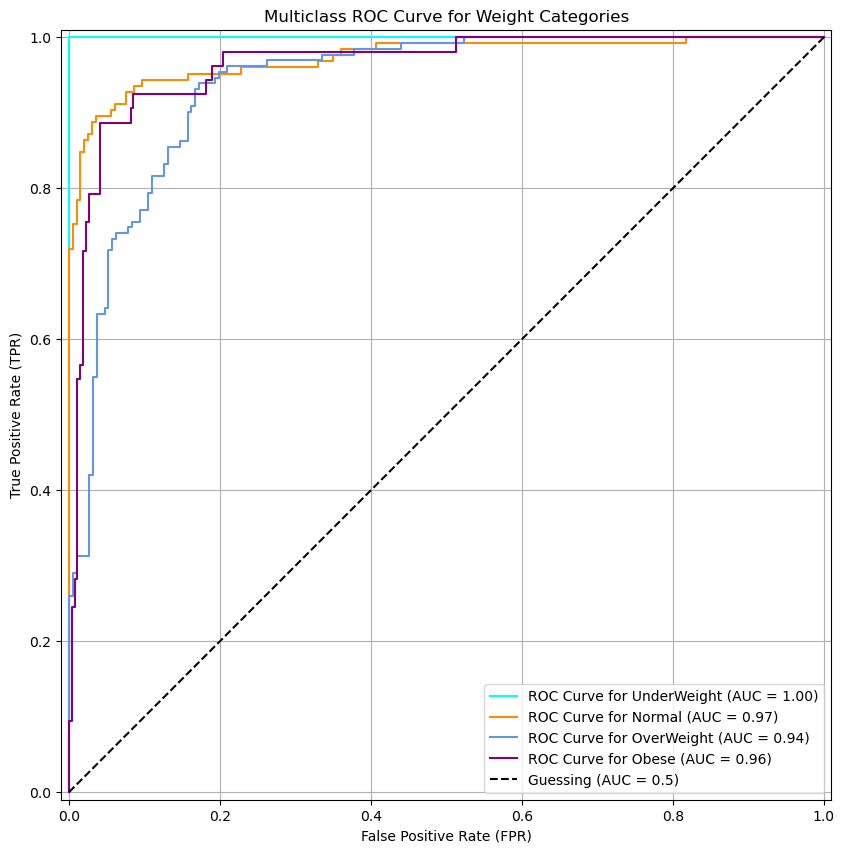

In [29]:
# Plot ROC curve and calculate and calculate AUC metric using RocCurveDisplay
fig, ax = plt.subplots(figsize = (10, 10))
colors = cycle(["aqua", "darkorange", "cornflowerblue", "purple"])

for class_id, color in zip(range(n_classes), colors):
    RocCurveDisplay.from_predictions( 
                               test_y_bin[:, class_id], 
                               prob_test_vec[:, class_id],
                               name = f"ROC Curve for {target_names[class_id]}",
                               color = color,
                               ax = ax)
    
# Add a diagonal line for random guessing
plt.plot([0, 1], [0,1], "k--", label = "Guessing (AUC = 0.5)")

# Formatting
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multiclass ROC Curve for Weight Categories")
plt.legend(loc = "lower right")
plt.grid()
plt.show();

### Confusion Matrix

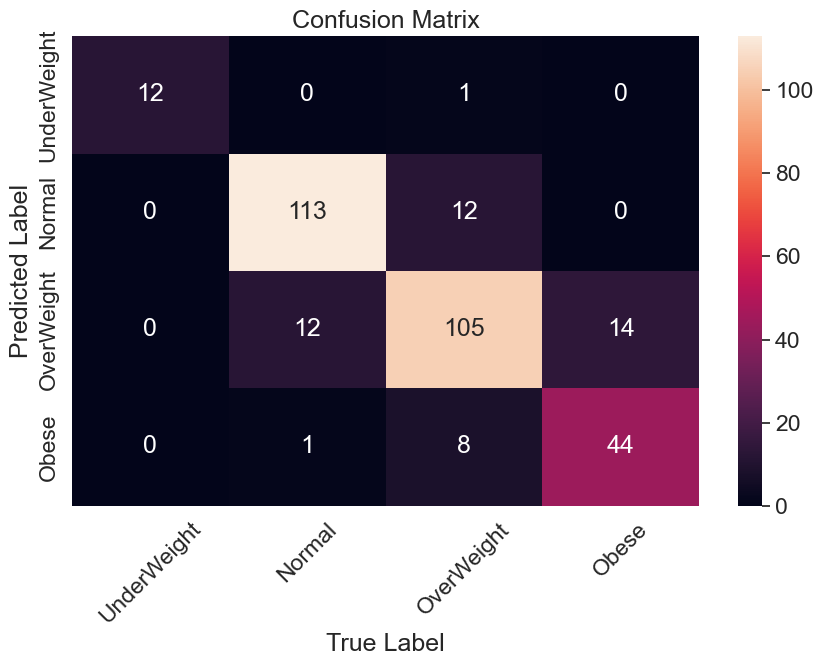

In [31]:
# Calculate and Display your confusion matrix

sns.set(font_scale = 1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize = (9, 7))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot = True,
                     fmt = "d",
                     cbar = True,
                     xticklabels = target_names,
                     yticklabels = target_names)
    plt.xlabel("True Label")
    plt.ylabel("Predicted Label")
    plt.title("Confusion Matrix")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show();

plot_conf_mat(y_test, y_preds)

### Classification Report

In [32]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           1       1.00      0.92      0.96        13
           2       0.90      0.90      0.90       125
           3       0.83      0.80      0.82       131
           4       0.76      0.83      0.79        53

    accuracy                           0.85       322
   macro avg       0.87      0.86      0.87       322
weighted avg       0.85      0.85      0.85       322



### Calculate Evaluation metrics using cross-validation

We're going to calculate precision, recall and f1-score of our model using cross-validation and to do so we'll be using `cross_val_score`.

In [34]:
clf = RandomForestClassifier(
                     n_estimators = 600,
                     min_samples_split = 2,
                     min_samples_leaf = 1,
                     max_features = 0.5,
                     max_depth = None)
clf

RandomForestClassifier(max_features=0.5, n_estimators=600)

In [35]:
# Cross-validated accuracy
cv_acc = cross_val_score(clf,
                         x,
                         y,
                         cv = 5,
                         scoring = "accuracy")
cv_acc

array([0.8757764 , 0.89751553, 0.83229814, 0.9068323 , 0.88509317])

In [36]:
# The mean accuracy is:
mean_cv_acc = np.mean(cv_acc)
mean_cv_acc

0.8795031055900621

**Using Precision, Recall, and F1-Score in Cross validation (Multi-class Data)**

In multi-class classification, we can use cross-validation to evaluate the model with `Precision`, `recall`, and `F1-score` using `Macro`, `Micro` and `Weighted` averaging.

Understanding `Macro`, `Micro`, and `Weighted` Averages
* `Macro` (Unweighted Mean): Averages metrics for each class equally, ignores class imbalance.
* `Micro` (Global Metric): Computes metrics based on total `TP`, `FP`, `FN`, treating all classes equally.
* `Weighted` (Class-proportion Weighted): Weighs each class based on support (number of samples)

In [44]:
# Cross-validated precision 
cv_precm = cross_val_score(clf,
                          x,
                          y,
                          scoring = "precision_micro")
cv_precm

array([0.87267081, 0.89130435, 0.83850932, 0.90062112, 0.89130435])

In [45]:
# THE mean of the cross validated precision is:
mean_cv_precm = np.mean(cv_precm)
mean_cv_precm

0.8788819875776397

In [46]:
# Cross-validated precision 
cv_precw = cross_val_score(clf,
                          x,
                          y,
                          scoring = "precision_weighted")
cv_precw

array([0.87615798, 0.89325676, 0.85350924, 0.90718722, 0.89772029])

In [47]:
# THE mean of the cross validated weighted precision is:
mean_cv_precw = np.mean(cv_precw)
mean_cv_precw

0.8855662969819292

In [48]:
# Cross-validated recall
cv_recm = cross_val_score(clf,
                         x,
                         y,
                         scoring = "recall_micro")
cv_recm

array([0.86645963, 0.87888199, 0.84782609, 0.90993789, 0.88819876])

In [49]:
# THE mean of the cross validated precision is:
mean_cv_recm = np.mean(cv_recm)
mean_cv_recm

0.8782608695652175

In [50]:
# Cross-validated recall
cv_recw = cross_val_score(clf,
                         x,
                         y,
                         scoring = "recall_weighted")
cv_recw

array([0.86956522, 0.88819876, 0.83540373, 0.89751553, 0.89440994])

In [51]:
# The mean of the cross validated recall is 
mean_cv_recw = np.mean(cv_recw)
mean_cv_recw

0.8770186335403727

In [52]:
# Cross-validated F1
cv_f1m = cross_val_score(clf,
                        x,
                        y,
                        scoring = "f1_micro")
cv_f1m

array([0.88198758, 0.88819876, 0.84782609, 0.90062112, 0.88819876])

In [53]:
# The mean of the cross validated f1 is:
mean_cv_f1m = np.mean(cv_f1m)
mean_cv_f1m

0.8813664596273292

In [54]:
# Cross-validated F1
cv_f1w = cross_val_score(clf,
                        x,
                        y,
                        scoring = "f1_weighted")
cv_f1w 

array([0.87020726, 0.88982178, 0.84308679, 0.89638258, 0.88863444])

In [55]:
# The mean of the cross validated f1 is:
mean_cv_f1w = np.mean(cv_f1w)
mean_cv_f1w

0.8776265703495746

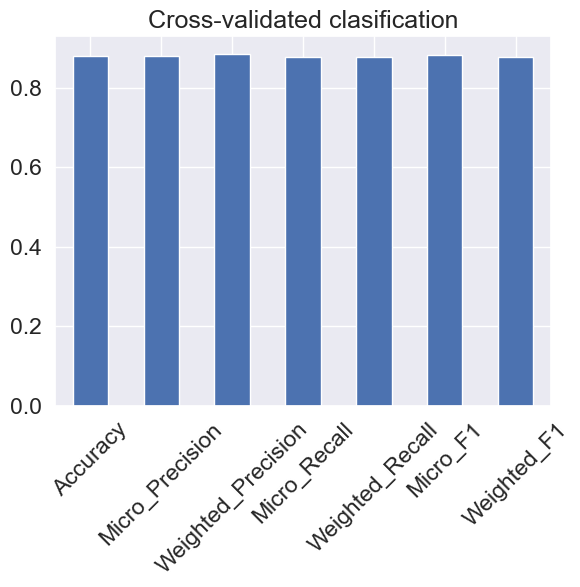

In [56]:
cv_metrics = pd.DataFrame({"Accuracy" : mean_cv_acc,
                           "Micro_Precision" : mean_cv_precm,
                           "Weighted_Precision" : mean_cv_precw,
                           "Micro_Recall" : mean_cv_recm,
                           "Weighted_Recall" : mean_cv_recw,
                           "Micro_F1": mean_cv_f1m,
                           "Weighted_F1": mean_cv_f1w},
                          index = [0])

cv_metrics.T.plot.bar(title = "Cross-validated clasification",
                      legend = False)
plt.xticks(rotation = 45);

## Feature Importance

Feature importance is another way of asking; 

> "which features contributed most to the outcomes of the model and how did they contribute".

Finding feature importance is different for each machine learning model.

Let's find the feature importance for our Ensemble model...

In [58]:
# Create a new classifier with the same parameters from hyperparameter tuning
clf = RandomForestClassifier(
                     n_estimators = 600,
                     min_samples_split = 2,
                     min_samples_leaf = 1,
                     max_features = 0.5,
                     max_depth = None,
                     random_state = 42)
clf

RandomForestClassifier(max_features=0.5, n_estimators=600, random_state=42)

In [59]:
# Train the model
clf.fit(x_train, y_train)

RandomForestClassifier(max_features=0.5, n_estimators=600, random_state=42)

In [60]:
# Get the feature importances
clf.feature_importances_

array([0.0430821 , 0.27173873, 0.11237605, 0.02528555, 0.03074848,
       0.09069383, 0.08446141, 0.05223781, 0.04562126, 0.04710561,
       0.01985088, 0.07313396, 0.03474557, 0.06891875])

In [62]:
# Match the importances of features to columns
feature_dict = dict(zip(x.columns, clf.feature_importances_))
feature_dict

{'Sex': 0.043082102812772846,
 'Age': 0.2717387283715176,
 'Height': 0.11237604953978293,
 'Overweight_Obese_Family': 0.02528554637667449,
 'Consumption_of_Fast_Food': 0.030748479774101736,
 'Frequency_of_Consuming_Vegetables': 0.0906938296622797,
 'Number_of_Main_Meals_Daily': 0.08446141237547761,
 'Food_Intake_Between_Meals': 0.05223781402876445,
 'Smoking': 0.04562125602601199,
 'Liquid_Intake_Daily': 0.04710561484797337,
 'Calculation_of_Calorie_Intake': 0.019850883737134555,
 'Physical_Excercise': 0.07313395856065166,
 'Schedule_Dedicated_to_Technology': 0.03474557083548891,
 'Type_of_Transportation_Used': 0.06891875305136824}

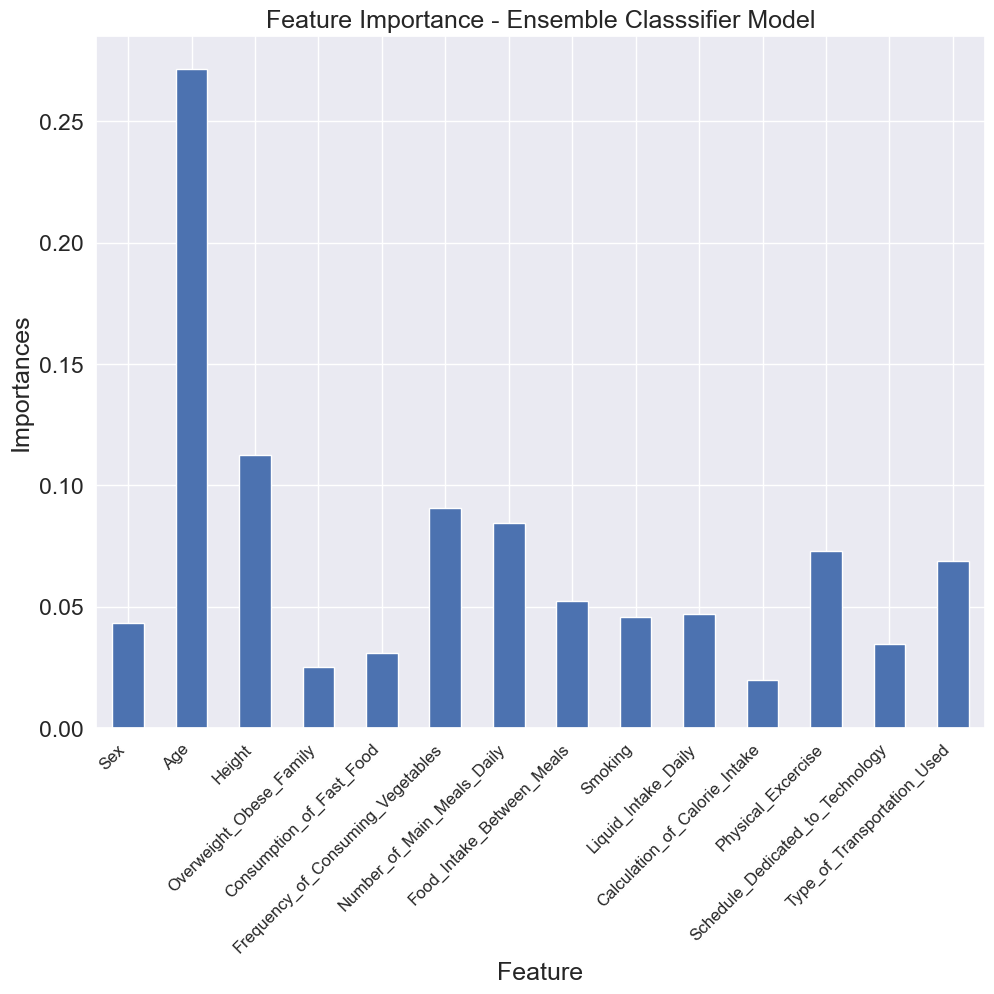

In [64]:
# Visualize feature importance
feature_df = pd.DataFrame(feature_dict , index = [0])
feature_df.T.plot.bar(figsize = (10,10), title = "Feature Importance - Ensemble Classsifier Model", legend = False);
plt.xticks(rotation = 45, ha = "right", fontsize = 12) # ha = horizontal alignment, right aligned
plt.tight_layout()
plt.xlabel("Feature")
plt.ylabel("Importances");